# EJERCICIO : ARBOL DE DECISIÓN PARA ECOMMERCE CHURN
## DATASET [kaggle](https://www.kaggle.com/datasets/upam22/ecommerce-customer-churn-data)

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [4]:
df = pd.read_csv('/content/ecom_churn_cleaned.csv')
df

,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,day_since_last_order,cashback_amount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,5.0,160
1,1,10.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,0.0,121
2,1,10.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3932,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,4.0,151
3933,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,5.0,225
3934,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,4.0,186
3935,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,9.0,179


# PASO 3: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

In [5]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['preferred_login_device', 'preferred_payment_mode', 'gender',
       'prefered_order_cat', 'marital_status'],
      dtype='object')

In [6]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
preferred_login_device
Mobile Phone    1706
Computer        1169
Phone           1062
Name: count, dtype: int64
**************************************************
preferred_payment_mode
Debit Card          1620
Credit Card          960
E wallet             450
COD                  308
UPI                  295
CC                   239
Cash on Delivery      65
Name: count, dtype: int64
**************************************************
gender
Male      2417
Female    1520
Name: count, dtype: int64
**************************************************
prefered_order_cat
Laptop & Accessory    1664
Mobile Phone          1107
Mobile                 702
Fashion                455
Grocery                  9
Name: count, dtype: int64
**************************************************
marital_status
Married     2012
Single      1350
Divorced     575
Name: count, dtype: int64


In [7]:
ordinal_cols = ['gender','marital_status']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['gender', 'marital_status'] ['preferred_payment_mode', 'prefered_order_cat', 'preferred_login_device']


In [8]:
import sklearn.compose
import sklearn.preprocessing

In [9]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['gender', 'marital_status']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['preferred_payment_mode',
                                  'prefered_order_cat',
                                  'preferred_login_device'])])

In [10]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__gender,ordinalencoder__marital_status,onehotencoder__preferred_payment_mode_CC,onehotencoder__preferred_payment_mode_COD,onehotencoder__preferred_payment_mode_Cash on Delivery,onehotencoder__preferred_payment_mode_Credit Card,onehotencoder__preferred_payment_mode_Debit Card,onehotencoder__preferred_payment_mode_E wallet,onehotencoder__preferred_payment_mode_UPI,onehotencoder__prefered_order_cat_Fashion,...,remainder__warehouse_to_home,remainder__hour_spend_on_app,remainder__number_of_device_registered,remainder__satisfaction_score,remainder__number_of_address,remainder__complain,remainder__order_amount_hike_fromlast_year,remainder__coupon_used,remainder__day_since_last_order,remainder__cashback_amount
0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,6.0,3.0,3.0,2.0,9.0,1.0,11.0,1.0,5.0,160.0
1,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,8.0,3.0,4.0,3.0,7.0,1.0,15.0,0.0,0.0,121.0
2,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,30.0,2.0,4.0,3.0,6.0,1.0,14.0,0.0,3.0,120.0
3,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,15.0,2.0,4.0,5.0,8.0,0.0,23.0,0.0,3.0,134.0
4,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.0,3.0,3.0,5.0,3.0,0.0,11.0,1.0,3.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3932,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,30.0,3.0,2.0,1.0,6.0,0.0,18.0,1.0,4.0,151.0
3933,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,13.0,3.0,5.0,5.0,6.0,0.0,16.0,1.0,5.0,225.0
3934,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,11.0,3.0,2.0,4.0,3.0,1.0,21.0,1.0,4.0,186.0
3935,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,9.0,4.0,5.0,4.0,4.0,0.0,15.0,2.0,9.0,179.0


In [11]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,gender,marital_status,preferred_payment_mode_CC,preferred_payment_mode_COD,preferred_payment_mode_Cash on Delivery,preferred_payment_mode_Credit Card,preferred_payment_mode_Debit Card,preferred_payment_mode_E wallet,preferred_payment_mode_UPI,prefered_order_cat_Fashion,...,warehouse_to_home,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,day_since_last_order,cashback_amount
0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,6.0,3.0,3.0,2.0,9.0,1.0,11.0,1.0,5.0,160.0
1,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,8.0,3.0,4.0,3.0,7.0,1.0,15.0,0.0,0.0,121.0
2,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,30.0,2.0,4.0,3.0,6.0,1.0,14.0,0.0,3.0,120.0
3,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,15.0,2.0,4.0,5.0,8.0,0.0,23.0,0.0,3.0,134.0
4,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.0,3.0,3.0,5.0,3.0,0.0,11.0,1.0,3.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3932,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,30.0,3.0,2.0,1.0,6.0,0.0,18.0,1.0,4.0,151.0
3933,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,13.0,3.0,5.0,5.0,6.0,0.0,16.0,1.0,5.0,225.0
3934,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,11.0,3.0,2.0,4.0,3.0,1.0,21.0,1.0,4.0,186.0
3935,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,9.0,4.0,5.0,4.0,4.0,0.0,15.0,2.0,9.0,179.0


In [12]:
data_transformed_df['churn'].value_counts()

,count
churn,
0.0,3199
1.0,738


In [13]:
data_transformed_df.dtypes

,0
gender,float64
marital_status,float64
preferred_payment_mode_CC,float64
preferred_payment_mode_COD,float64
preferred_payment_mode_Cash on Delivery,float64
preferred_payment_mode_Credit Card,float64
preferred_payment_mode_Debit Card,float64
preferred_payment_mode_E wallet,float64
preferred_payment_mode_UPI,float64
prefered_order_cat_Fashion,float64


In [14]:
corr_matrix = data_transformed_df.corr()
corr_churn = corr_matrix['churn']
corr_churn.sort_values(ascending=False)

,churn
churn,1.000000
complain,0.262246
marital_status,0.134560
satisfaction_score,0.131555
prefered_order_cat_Mobile Phone,0.122312
prefered_order_cat_Mobile,0.118015
number_of_device_registered,0.097851
warehouse_to_home,0.081101
preferred_payment_mode_COD,0.070926
preferred_login_device_Phone,0.068811


<Axes: >

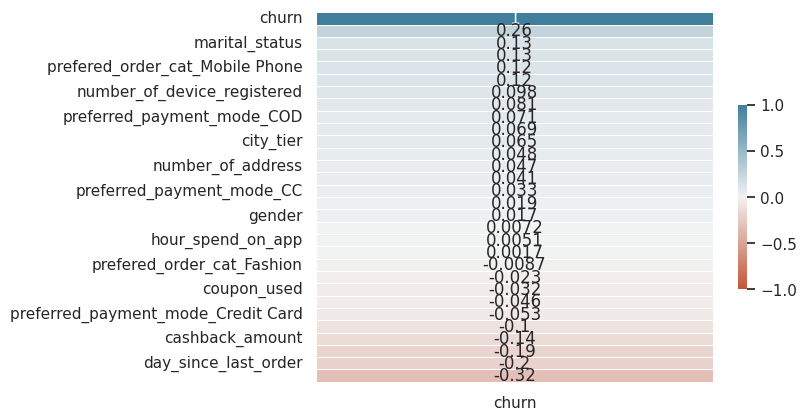

In [15]:
sns.heatmap(
    data=corr_churn.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [16]:
cols = corr_churn.index.tolist()
cols.remove('churn')
cols

['gender',
 'marital_status',
 'preferred_payment_mode_CC',
 'preferred_payment_mode_COD',
 'preferred_payment_mode_Cash on Delivery',
 'preferred_payment_mode_Credit Card',
 'preferred_payment_mode_Debit Card',
 'preferred_payment_mode_E wallet',
 'preferred_payment_mode_UPI',
 'prefered_order_cat_Fashion',
 'prefered_order_cat_Grocery',
 'prefered_order_cat_Laptop & Accessory',
 'prefered_order_cat_Mobile',
 'prefered_order_cat_Mobile Phone',
 'preferred_login_device_Computer',
 'preferred_login_device_Mobile Phone',
 'preferred_login_device_Phone',
 'tenure',
 'city_tier',
 'warehouse_to_home',
 'hour_spend_on_app',
 'number_of_device_registered',
 'satisfaction_score',
 'number_of_address',
 'complain',
 'order_amount_hike_fromlast_year',
 'coupon_used',
 'day_since_last_order',
 'cashback_amount']

In [17]:
X = data_transformed_df[cols]
y = data_transformed_df['churn']

# ENTRENAMIENTO DE MODELO DE ARBOL DE DECISIÓN

In [18]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE para balancear las clases en los datos de entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Conteo de clases en y_train antes de SMOTE:")
print(y_train.value_counts())
print("\nConteo de clases en y_train después de SMOTE:")
print(y_train_resampled.value_counts())

# Actualizar X_train y y_train con los datos resampleados
X_train = X_train_resampled
y_train = y_train_resampled

Conteo de clases en y_train antes de SMOTE:
churn
0.0    2574
1.0     575
Name: count, dtype: int64

Conteo de clases en y_train después de SMOTE:
churn
0.0    2574
1.0    2574
Name: count, dtype: int64


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [23]:
param_grid = {
    'max_depth': [3,4,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'criterion':['gini','entropy']
}

clf = DecisionTreeClassifier(random_state=42)

In [24]:
grid_search = GridSearchCV(clf,param_grid,cv=5,scoring='accuracy',n_jobs=1)
grid_search.fit(X_train,y_train)
print(f'Mejor combinación de parámetros: {grid_search.best_params_}')

Mejor combinación de parámetros: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [26]:
from sklearn.metrics import accuracy_score
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Exactitud del modelo: {accuracy}')

Exactitud del modelo: 0.9149746192893401


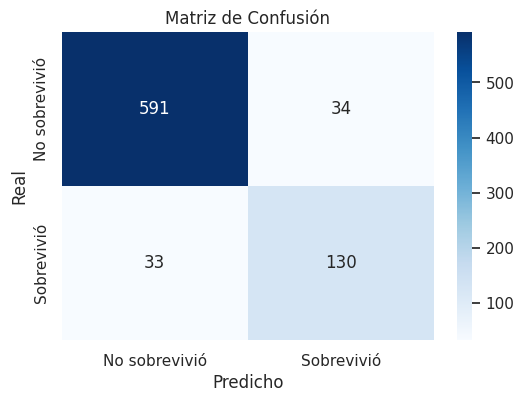

In [27]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()